# 14강 최신 딥러닝: Transformer

14강에서는 **Transformer 모델**에 대한 개념부터 PyTorch를 이용한 실제 코드 구현 예시까지 간략히 다룬다. 구체적으로, **Part 1**에서는 기본적인 **Vanilla Transformer**의 기본 작동 원리를, **Part 2**에서는 실제 예제 코드를 통해 **PyTorch**로 직접 모델을 구성하고 학습 및 추론해보는 과정을 살펴본다.

# Part 1. Transformer 기본 원리

## 1.1 서론

**Transformer**는 2017년 Vaswani et al.의 논문 "**Attention Is All You Need**"에서 처음 제안된, **Attention 메커니즘**을 기반으로 하는 **인코더-디코더(Encoder-Decoder)** 모델이다.  
- 기존의 RNN/LSTM 계열과 달리 **Self-Attention**을 통해 병렬 처리가 가능하며, 긴 시퀀스에서도 **장거리 의존성**을 효율적으로 학습할 수 있다.

## 1.2 Vanilla Transformer의 구조

트랜스포머는 크게 **인코더**(Encoder)와 **디코더**(Decoder)라는 두 개의 주요 블록으로 구성된다.

![Transformer Diagram](transformer_diagram.png)

- **Encoder**  
  - 입력 시퀀스를 **Self-Attention**과 **Feed-Forward Network**를 통해 임베딩 벡터로 변환한다.  
- **Decoder**  
  - **Masked Self-Attention**으로 미래 정보를 가리는 동시에, **Encoder-Decoder Attention**을 통해 인코더가 만들어놓은 정보를 참조하여 최종 출력을 생성한다.

## 1.3 핵심 구성 요소 

1. **임베딩(Embedding)**  
   - 단어(혹은 토큰)을 고정 크기 벡터로 매핑한다.
2. **포지셔널 인코딩(Positional Encoding)**  
   - 순서를 내재하지 않는 트랜스포머에게 위치 정보를 부여하기 위해, 임베딩 벡터에 위치 신호를 더한다.
3. **멀티헤드 어텐션(Multi-Head Attention)**  
   - 여러 개의 어텐션 헤드를 병렬로 사용하여, 다양한 관점에서 토큰 간 상호작용을 학습한다.
   - **Self-Attention**(Encoder, Decoder), **Masked Self-Attention**(Decoder에서 미래 정보 차단), **Encoder-Decoder Attention**(Decoder가 Encoder 출력 참조) 등이 있다.
4. **위치별 피드포워드 네트워크(Position-wise FFN)**  
   - 각 토큰 위치에 대해 독립적으로 2-layer MLP를 적용하여 비선형 변환을 수행한다.
5. **잔차 연결 + 레이어 정규화(Residual + LayerNorm)**  
   - 입력에 서브레이어 출력을 더해주는 **잔차 연결**은 깊은 네트워크 학습을 안정화한다.
   - **레이어 정규화**는 모델의 수렴을 빠르게 하며, 학습 안정성을 높여준다.

## 1.4 인코더(Encoder) 

### 인코더 구조 요약
- **입력 임베딩** + **포지셔널 인코딩**  
- **Self-Attention**  
- **Feed-Forward Network(FFN)**  
- **Residual & Layer Normalization**  
- 여러 계층(`n_enc_layers`) 반복

In [1]:
# 절차 예시 (개념적 코드)
def encoder(enc_inp):
    # 인코더 입력 (x_enc) 준비
    x_enc = embedding(enc_inp) * sqrt(d_model)
    x_enc = x_enc + pos_encoding(x_enc)
    x_enc = dropout(x_enc)
    
    # 인코더 레이어 반복
    for _ in range(n_enc_layers):
        # 1) Multi-Head Self-Attention
        attn_enc = multi_head_attention(x_enc, x_enc, x_enc, mask=None)
        attn_enc = dropout(attn_enc)
        attn_enc = layer_normalization(x_enc + attn_enc)
    
        # 2) Feed-Forward
        ff_enc = pointwise_ff(attn_enc)
        x_enc = layer_normalization(attn_enc + ff_enc)
    
    enc_out = x_enc
    return enc_out


## 1.5 디코더(Decoder) 

### 디코더 구조 요약
- **입력 임베딩** + **포지셔널 인코딩**  
- **Masked Self-Attention** (미래 토큰을 가리는 **causal mask**)  
- **Encoder-Decoder Attention** (인코더 출력 참조)  
- **Feed-Forward Network(FFN)**  
- **Residual & Layer Normalization**  
- 여러 계층(`n_dec_layers`) 반복  
- **출력(Dense & Softmax)**

In [2]:
# 절차 예시 (개념적 코드)
def decoder(dec_inp):
    x_dec = embedding(dec_inp) * sqrt(d_model)
    x_dec = x_dec + pos_encoding(x_dec)
    x_dec = dropout(x_dec)
    mask = causal_mask(x_dec)
    
    for _ in range(n_dec_layers):
        # 1) Masked Self-Attention
        attn1 = multi_head_attention(x_dec, x_dec, x_dec, mask)
        attn1 = layer_normalization(attn1 + x_dec)
    
        # 2) Encoder-Decoder Attention
        attn2 = multi_head_attention(attn1, enc_out, enc_out, None)
        attn2 = dropout(attn2)
        attn2 = layer_normalization(attn1 + attn2)
    
        # 3) Feed-Forward
        ff_dec = pointwise_ff(attn2)
        x_dec = layer_normalization(attn2 + ff_dec)
    
    logits = dense(x_dec)
    probs = softmax(logits, dim=-1)
    return probs


## 1.6 전체 코드 흐름 (개념) 

In [3]:
def vanilla_transformer(enc_inp, dec_inp, n_enc_layers, n_dec_layers, d_model):
    # ====== ENCODER ======
    x_enc = embedding(enc_inp) * sqrt(d_model)
    x_enc = x_enc + pos_encoding(x_enc)
    x_enc = dropout(x_enc)
    
    for _ in range(n_enc_layers):
        # Self-Attention + FFN
        attn_enc = multi_head_attention(x_enc, x_enc, x_enc, mask=None)
        attn_enc = dropout(attn_enc)
        attn_enc = layer_normalization(x_enc + attn_enc)

        ff_enc = pointwise_ff(attn_enc)
        x_enc = layer_normalization(attn_enc + ff_enc)
    enc_out = x_enc

    # ====== DECODER ======
    x_dec = embedding(dec_inp) * sqrt(d_model)
    x_dec = x_dec + pos_encoding(x_dec)
    x_dec = dropout(x_dec)
    
    for _ in range(n_dec_layers):
        # Masked Self-Attention
        attn1 = multi_head_attention(x_dec, x_dec, x_dec, mask=causal_mask(x_dec))
        attn1 = layer_normalization(attn1 + x_dec)
        
        # Encoder-Decoder Attention
        attn2 = multi_head_attention(attn1, enc_out, enc_out, mask=None)
        attn2 = dropout(attn2)
        attn2 = layer_normalization(attn1 + attn2)
        
        # Feed-Forward
        ff_dec = pointwise_ff(attn2)
        x_dec = layer_normalization(attn2 + ff_dec)
    
    logits = dense(x_dec)
    probs = softmax(logits, dim=-1)
    return probs

**내용 정리**  
- 트랜스포머는 **Self-Attention**과 **Feed-Forward**를 레이어마다 쌓는 구조  
- **마스킹**(masking)으로 필요에 따라 일부 토큰을 무시하거나, 미래 정보를 차단 
- **잔차 연결 + 레이어 정규화**를 통해 학습 안정화  
- 최종적으로 **확률 분포**를 산출하여 다음 단어나 출력 토큰을 예측


# Part 2. Transformer 파이썬 구현

이제부터 실제 **PyTorch** 코드 예시를 통해, Transformer를 직접 구현하고 간단한 샘플로 학습해보는 과정을 살펴보자.


## 2.1 라이브러리 임포트 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (2, 2)

## 2.2 데이터 전처리 및 하이퍼파라미터 설정

In [2]:
# 예제 문장 (독일어 -> 영어 번역)
sentences = ['das ist ein buch P',  # 인코더 입력 (P: padding)
             'S that is a book',    # 디코더 입력 (S: start)
             'that is a book E']    # 디코더 목표 출력 (E: end)

# 단어 사전
src_vocab = {'P': 0, 'das': 1, 'ist': 2, 'ein': 3, 'buch': 4}
tgt_vocab = {'P': 0, 'that': 1, 'is': 2, 'a': 3, 'book': 4, 'S': 5, 'E': 6}
# 디코더 결과를 다시 단어로 매핑하기 위한 역 사전
number_dict = {i: w for i, w in enumerate(tgt_vocab)}

src_vocab_size = len(src_vocab)  # 5
tgt_vocab_size = len(tgt_vocab)  # 7

# Transformer 하이퍼파라미터 설정
src_len = 5  # 입력 문장 길이
tgt_len = 5  # 출력 문장 길이
d_model = 64 # 일반적인 경우에는 512
n_heads = 2 # 일반적인 경우에는 8
d_ff = 2048 # FC 노드 갯수 (논문대로 2048)
n_layers = 2 # 일반적인 경우에는 6

## 2.3 Batch 생성 함수 

주어진 문장들을 숫자 인덱스 텐서로 변환하여 (enc_inputs, dec_inputs, target)을 반환

In [3]:
def make_batch(sentences):
    input_batch = [[src_vocab[n] for n in sentences[0].split()]]
    output_batch = [[tgt_vocab[n] for n in sentences[1].split()]]
    target_batch = [[tgt_vocab[n] for n in sentences[2].split()]]
    return (torch.LongTensor(input_batch), 
            torch.LongTensor(output_batch), 
            torch.LongTensor(target_batch))

enc_inputs, dec_inputs, target_batch = make_batch(sentences)
print('Encoder Inputs:', enc_inputs)
print('Decoder Inputs:', dec_inputs)
print('Target Batch:', target_batch)

Encoder Inputs: tensor([[1, 2, 3, 4, 0]])
Decoder Inputs: tensor([[5, 1, 2, 3, 4]])
Target Batch: tensor([[1, 2, 3, 4, 6]])


## 2.4 Positional Encoding 

In [4]:
def get_sinusoid_encoding_table(n_position, d_model):
    def cal_angle(position, hid_idx):
        return position / np.power(10000, 2*(hid_idx//2)/d_model)
    def get_posi_angle_vec(position):
        return [cal_angle(position, hid_j) for hid_j in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2]) # 짝수
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2]) # 홀수
    return torch.FloatTensor(sinusoid_table)

pos_encoding = get_sinusoid_encoding_table(src_len + 1, d_model)
print('Positional Encoding Shape:', pos_encoding.shape)

Positional Encoding Shape: torch.Size([6, 64])


### 2.4.1 Positional Encoding 시각화 예제

아래 코드는 **Positional Encoding** 테이블을 2차원 컬러맵 형태로 시각화한다.  
- **가로 축**(Embedding Dimension): 임베딩 벡터의 차원(d_model)  
- **세로 축**(Position): 시퀀스에서의 위치 인덱스(n_position)

각 위치(행)에 대해, $\sin$ 또는 $\cos$ 함수를 사용한 다양한 주파수의 값들이 임베딩 차원(열)에 대응된다.  
이렇게 위치별로 서로 다른 패턴을 가지는 인코딩을 덧붙여, 트랜스포머는 **토큰 순서 정보**를 학습할 수 있다.


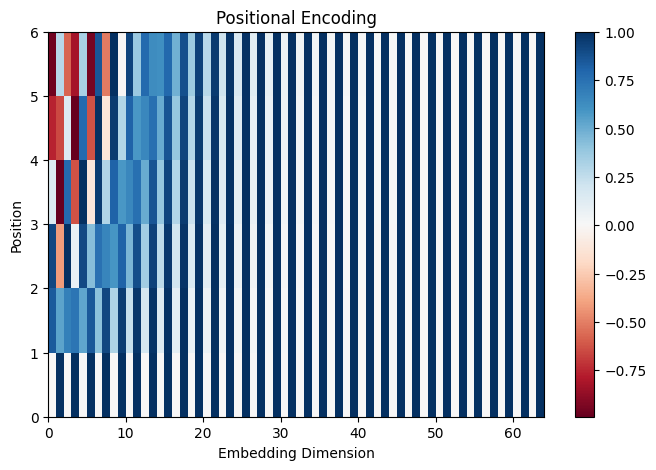

In [5]:
# 예: Positional Encoding 시각화
def plot_positional_encoding(pos_enc, d_model, n_position):
    """
    pos_enc: (n_position, d_model) 형태의 위치 인코딩 테이블
    """
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(pos_enc.numpy(), cmap='RdBu')  # 2D 컬러맵
    plt.xlabel('Embedding Dimension')
    plt.xlim((0, d_model))
    plt.ylabel('Position')
    plt.ylim((0, n_position))
    plt.colorbar()
    plt.title("Positional Encoding")
    plt.show()

# pos_encoding: (src_len+1, d_model)
plot_positional_encoding(pos_encoding, d_model, src_len + 1)


## 2.5 어텐션 마스크 생성

트랜스포머는 어텐션 연산에서 특정 위치를 무시하거나(예: `PAD` 토큰), 미래 정보에 접근하지 못하도록(autoregressive 특성) 마스킹을 적용한다. 아래 두 함수는 이러한 마스킹을 수행하기 위한 유틸리티 함수이다.

In [6]:
def get_attn_pad_mask(seq_q, seq_k):
   # seq_q와 seq_k에서 PAD(=0) 토큰 위치를 마스킹
   batch_size, len_q = seq_q.size()
   batch_size, len_k = seq_k.size()
   pad_attn_mask = seq_k.data.eq(0).unsqueeze(1)  # (B, 1, T_k)
   return pad_attn_mask.expand(batch_size, len_q, len_k)  # (B, T_q, T_k)


**`get_attn_pad_mask(seq_q, seq_k)`**  
   - **입력**:  
     - `seq_q`: 쿼리(Query) 시퀀스 (batch_size, len_q)  
     - `seq_k`: 키(Key) 시퀀스 (batch_size, len_k)  
   - **역할**:  
     - 키 시퀀스(`seq_k`)에서 `PAD` 토큰에 해당하는 위치(여기서는 값이 0인 위치)를 찾아, 해당 위치를 `True`(마스킹 대상)로 설정한다.  
     - 이렇게 생성된 마스크는 **(batch_size, len_q, len_k)** 형태로 확장되어, 쿼리의 각 토큰이 키의 `PAD` 위치를 보지 않도록 해준다.  

In [7]:
def get_attn_subsequent_mask(seq):
    # 디코더용: 현재 시점 이후 위치를 마스킹
    attn_shape = [seq.size(1), seq.size(1)] # (T, T)
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype(bool)
    return torch.from_numpy(subsequent_mask)  # (T, T)

**`get_attn_subsequent_mask(seq)`**  
- **입력**:
  - `seq`: 디코더 입력 시퀀스 (shape: `(batch_size, T)`)  

- **역할**: 
  - 디코더에서 **현재 시점 이후의 토큰**을 가리지 않도록(미래 시점 토큰을 보지 못하도록) 마스크를 생성한다.  
  - 즉, 시퀀스 길이 `T`에 대해 `(T, T)` 형태의 상삼각형(mask)을 만들어,  
    상삼각 부분(대각선 위 영역)을 `True`로 설정하여 **현재 시점 이후를 모두 마스킹**한다.  

- **구현**: 
  - `attn_shape = [seq.size(1), seq.size(1)]`  
     - 디코더 시퀀스 길이 `T`를 이용하여 `(T, T)` 형태를 결정한다.
  - `np.triu(np.ones(attn_shape), k=1).astype(bool)`  
     - `np.ones`로 `(T, T)` 크기의 배열을 만든 후, `np.triu(..., k=1)`를 통해 위삼각 부분(대각선을 제외한 부분)을 추출한다.  
     - 결과적으로 (T, T) 배열에서 상삼각 영역은 `1(True)`, 그 외 하삼각 영역은 `0(False)`가 된다.
  - `torch.from_numpy(subsequent_mask)`  
     - 넘파이 배열을 **PyTorch 텐서**로 변환하여 리턴한다.  
  - **결과**: `(T, T)` 형태의 불리언 마스크  
     - `True`인 위치는 **마스킹 대상**이므로 디코더는 미래 시점(현재 시점 이후)을 볼 수 없게 된다.

## 2.6 Encoder 및 Decoder 레이어 구성

### 2.6.1 Encoder Layer   

**인코더 레이어**는 트랜스포머 인코더를 구성하는 최소 단위로, **Multi-Head Self-Attention**과 **Feed-Forward Network**를 포함한다.


In [8]:
class EncoderLayer(nn.Module):
    def __init__(self):
        super(EncoderLayer, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, self_attn_mask):
        # --------- (핵심) 마스크 차원을 (B*n_heads, T, T)로 맞춰준다 ----------
        # 일단 (B, T, T)를 (B*n_heads, T, T)로 확장
        # B, T, T => (B*n_heads, T, T)
        if self_attn_mask is not None:
            B, T, S = self_attn_mask.shape  # 예) (1, 5, 5)
            self_attn_mask = self_attn_mask.repeat(n_heads, 1, 1)  
            # 이제 (2, 5, 5)가 되어, MHA가 요구하는 (batch_size * num_heads, T, S)에 맞게 된다.

        # Self-Attention + Residual/LayerNorm
        attn_output, attn_weights = self.self_attn(x, x, x, attn_mask=self_attn_mask)
        x = self.norm1(x + attn_output)
        
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        return x, attn_weights


#### 내용 해설   


1. **EncoderLayer 클래스 선언**
   - `EncoderLayer`는 `nn.Module`을 상속받아, Transformer 인코더에서 **한 층(layer)** 을 구성하는 역할을 한다.
   - 인코더 층은 “Self-Attention → Feed Forward” 두 단계로 나뉘며, 각각 Residual Connection과 Layer Normalization을 적용한다.

2. **생성자(`__init__`)**
   - **`self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)`**  
     - PyTorch의 내장 `MultiheadAttention` 모듈을 사용하여 **멀티헤드 어텐션**을 구현한다.  
     - `d_model`: 임베딩 차원, `n_heads`: 어텐션 헤드(head) 수, `batch_first=True`는 입력 텐서가 `(batch_size, seq_len, embedding_dim)` 형식임을 의미한다.
   - **`self.norm1 = nn.LayerNorm(d_model)`**  
     - **Layer Normalization**을 수행하는 모듈이다.  
     - Self-Attention 결과와 Residual을 합친 뒤 정규화할 때 사용한다.
   - **`self.ffn = nn.Sequential(...)`**  
     - **Feed Forward Network**이며, 보통 `d_model → d_ff → d_model` 구조로 이루어진다.  
     - 중간에 활성화 함수 `ReLU`를 넣어 비선형성을 추가한다.
   - **`self.norm2 = nn.LayerNorm(d_model)`**  
     - Feed Forward 결과를 다시 입력과 합치고, 그 합을 정규화하기 위해 사용하는 Layer Normalization 모듈이다.

3. **순전파(`forward`)**
   - **인자**  
     - `x`: 입력 텐서. 보통 `(batch_size, seq_len, d_model)` 형태의 인코더 입력(임베딩 벡터).
     - `self_attn_mask`: Self-Attention 시 사용될 마스크 텐서로, `(B, T, T)` 형태.
   - **마스크 확장**  
     ```python
     if self_attn_mask is not None:
         B, T, S = self_attn_mask.shape  # 예) (1, 5, 5)
         self_attn_mask = self_attn_mask.repeat(n_heads, 1, 1)
         # 이제 (2, 5, 5)가 되어, MHA가 요구하는 (batch_size * num_heads, T, S)에 맞게 된다.
     ```
     - PyTorch `MultiheadAttention`가 3D 마스크를 받는 경우,  
       `(batch_size * num_heads, T, S)` 형태를 요구하는 환경에서  
       기존 `(B, T, T)` 마스크를 `n_heads`만큼 반복(`repeat`)하여 `(B*n_heads, T, T)`로 확장한다.  
     - 이렇게 하면 모든 헤드에서 동일한 마스크를 적용할 수 있다.
   - **Self-Attention & Residual/LayerNorm**
     ```python
     attn_output, attn_weights = self.self_attn(x, x, x, attn_mask=self_attn_mask)
     x = self.norm1(x + attn_output)
     ```
     - 쿼리(Q)·키(K)·밸류(V)에 같은 텐서 `x`를 전달하므로 **Self-Attention**이 된다.  
     - `attn_mask`에 의해 특정 위치(예: 패딩, 미래 시점 등)를 가리는 역할을 할 수 있다.
     - 결과 `attn_output`을 입력 `x`에 다시 더하고, `LayerNorm`을 통해 정규화한다 (Residual Connection).
   - **Feed Forward & Residual/LayerNorm**
     ```python
     ffn_output = self.ffn(x)
     x = self.norm2(x + ffn_output)
     ```
     - `ffn`을 거친 결과를 다시 입력에 더해 Residual Connection을 형성하고, `LayerNorm`을 적용하여 최종 출력을 얻는다.
   - **반환 값**  
     ```python
     return x, attn_weights
     ```
     - 최종적으로 **정규화**된 출력(`x`)과 **어텐션 가중치**(`attn_weights`)를 함께 반환한다.

4. **핵심 요약**
   - **Self-Attention**: 입력 `x`끼리 서로 어텐션을 주고받으며 문맥 정보를 풍부하게 한다.
   - **Residual + LayerNorm**: 안정적인 학습을 위해 결과를 다시 입력에 더하고 정규화하는 과정을 두 번(어텐션 후, FFN 후) 진행한다.
   - **마스크 확장**: 일부 설정에서 `MultiheadAttention`이 (B*n_heads, T, S) 형태의 마스크를 필요로 하므로, (B, T, T) 마스크를 `repeat(n_heads, 1, 1)`로 확장하는 과정을 거친다.



### 2.6.2 Decoder Layer   

**디코더 레이어**는 트랜스포머 디코더를 구성하는 최소 단위로, **Masked Self-Attention**과 **Encoder-Decoder Attention**, 그리고 **Feed-Forward Network**를 포함한다.


In [9]:
class DecoderLayer(nn.Module):
    def __init__(self):
        super(DecoderLayer, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.enc_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, dec_x, enc_output, self_attn_mask, enc_attn_mask):
        # ---- (1) 디코더 Self-Attention 마스크 (B, T, T) -> (B*n_heads, T, T) ----
        if self_attn_mask is not None:
            B, T, S = self_attn_mask.shape
            self_attn_mask = self_attn_mask.repeat(n_heads, 1, 1)

        # ---- (2) 인코더-디코더 어텐션 마스크 (B, T, S) -> (B*n_heads, T, S) ----
        if enc_attn_mask is not None:
            B2, T2, S2 = enc_attn_mask.shape
            enc_attn_mask = enc_attn_mask.repeat(n_heads, 1, 1)

        # 디코더 Self-Attention
        self_attn_output, self_attn = self.self_attn(dec_x, dec_x, dec_x, attn_mask=self_attn_mask)
        dec_x = self.norm1(dec_x + self_attn_output)
        
        # 인코더-디코더 Attention
        enc_attn_output, enc_attn = self.enc_attn(dec_x, enc_output, enc_output, attn_mask=enc_attn_mask)
        dec_x = self.norm2(dec_x + enc_attn_output)
        
        # Feed Forward
        ffn_output = self.ffn(dec_x)
        dec_x = self.norm3(dec_x + ffn_output)
        return dec_x, self_attn, enc_attn

#### 내용 해설  

1. **클래스 구조**
  - **Self-Attention**: `self.self_attn`  
  - **인코더-디코더 어텐션**: `self.enc_attn`  
  - **Feed Forward Network(FFN)**: `self.ffn`  
  - 각 단계 뒤에는 **Residual Connection + LayerNorm**을 적용 (`norm1`, `norm2`, `norm3`).

2. **마스크 처리**
```python
if self_attn_mask is not None:
    self_attn_mask = self_attn_mask.repeat(n_heads, 1, 1)

if enc_attn_mask is not None:
    enc_attn_mask = enc_attn_mask.repeat(n_heads, 1, 1)
```
  - (B, T, T) 또는 (B, T, S) 형태의 마스크를 (B*n_heads, T, T/S)로 확장.
  - 디코더 Self-Attention 부분: 미래 시점 마스크와 패딩 마스크를 결합해 사용.
  - 인코더-디코더 Attention 부분: 디코더가 인코더의 패딩 위치를 보지 않도록 하는 마스크.

3. **순전파(forward)**
  - 디코더 Self-Attention
    - 쿼리(Q)·키(K)·밸류(V)가 dec_x로 동일한 디코더 내부 어텐션이다.
    - 미래 토큰(미래 시점)과 패딩 토큰을 마스킹하여, 디코더가 아직 생성되지 않은 단어를 보지 못하게 한다.
  - 인코더-디코더 Attention
    - 쿼리(Q)는 디코더의 현재 상태(dec_x), 키(K)·밸류(V)는 인코더 출력(enc_output)이며, 이들을 기반으로 어텐션 연산을 수행한다.
    - 이 과정을 통해 디코더는 **인코더가 추출한 정보**(context)를 참조하여 다음 단어를 예측하는 데 필요한 정보를 얻는다.  
    - 인코더 입력에서의 패딩 위치를 마스킹하여, 디코더가 불필요한 정보에 주목하지 않도록 한다.
  - Feed Forward
    - 멀티헤드 어텐션을 거친 출력(`dec_x`)에 FFN을 통해 비선형 변환을 적용한 후, 남은 부분은 인코더 레이어와 유사하게 Residual + LayerNorm을 수행한다.

4. **출력**  
  - `dec_x`: 해당 디코더 레이어를 통과한 최종 벡터  
  - `self_attn`: 디코더의 마스킹된 자기 어텐션 가중치  
  - `enc_attn`: 인코더-디코더 어텐션 가중치  

5. **핵심 요약**
  - 여러 개의 디코더 레이어를 쌓아서 최종 **디코더**를 구성하며, 각 레이어에서 인코더의 정보와 디코더의 이전 단계 정보를 결합해 **목표 시퀀스**를 점진적으로 생성할 수 있게 된다.

## 2.7 Encoder 및 Decoder 구성 

### 2.7.1 Encoder

In [10]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.src_emb = nn.Embedding(src_vocab_size, d_model)
        self.pos_emb = nn.Embedding.from_pretrained(
            get_sinusoid_encoding_table(src_len + 1, d_model),
            freeze=True
        )
        self.layers = nn.ModuleList([EncoderLayer() for _ in range(n_layers)])

    def forward(self, enc_inputs):
        # 위치 임베딩
        positions = torch.arange(enc_inputs.size(1), device=enc_inputs.device)\
                          .unsqueeze(0).expand(enc_inputs.size(0), -1) + 1
        output = self.src_emb(enc_inputs) + self.pos_emb(positions)

        # (B, T, T)
        enc_self_attn_mask = get_attn_pad_mask(enc_inputs, enc_inputs)

        attn_weights_list = []
        for layer in self.layers:
            output, attn_weights = layer(output, enc_self_attn_mask)
            attn_weights_list.append(attn_weights)

        return output, attn_weights_list

#### 내용 해설

- **임베딩(`src_emb`) + 위치 임베딩(`pos_emb`)**  
  - 입력 시퀀스(`enc_inputs`)를 단어 임베딩으로 변환하고, 위치 정보(포지셔널 인코딩)를 더해 Transformer 인코더 입출력 형식에 맞춘다.
- **`enc_self_attn_mask`**  
  - 입력 내의 PAD 위치(값이 0인 부분)를 마스킹해, 인코더가 패딩 토큰을 무시하도록 한다.  
  - 형태: `(batch_size, seq_len, seq_len)`.
- **`self.layers = nn.ModuleList([...])`**  
  - 인코더 레이어(`EncoderLayer`)를 여러 개 쌓는다.  
  - 각 레이어에서 Self-Attention 및 Feed Forward 과정을 거쳐, Residual + LayerNorm을 적용한다.
- **`forward`**  
  1. 위치 임베딩 계산 후, `enc_self_attn_mask` 생성  
  2. **루프**를 통해 모든 인코더 레이어를 순차적으로 통과  
  3. 레이어별로 **출력(`output`)**과 **어텐션 가중치(`attn_weights`)**를 얻고, 최종 결과를 반환  

이로써 인코더는 입력 문장의 **고수준 표현**(contextual representation)을 생성하며, 이후 디코더에서 참조할 **어텐션 가중치**를 함께 확인할 수 있다.


### 2.7.2 Decoder

In [11]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_emb = nn.Embedding.from_pretrained(
            get_sinusoid_encoding_table(tgt_len + 1, d_model),
            freeze=True
        )
        self.layers = nn.ModuleList([DecoderLayer() for _ in range(n_layers)])

    def forward(self, dec_inputs, enc_inputs, enc_outputs):
        # 위치 임베딩
        positions = torch.arange(dec_inputs.size(1), device=dec_inputs.device)\
                          .unsqueeze(0).expand(dec_inputs.size(0), -1) + 1
        dec_output = self.tgt_emb(dec_inputs) + self.pos_emb(positions)

        # 디코더 마스크
        dec_self_attn_pad_mask = get_attn_pad_mask(dec_inputs, dec_inputs)  
        dec_self_attn_sub_mask = get_attn_subsequent_mask(dec_inputs).to(dec_inputs.device)
        dec_self_attn_sub_mask = dec_self_attn_sub_mask.unsqueeze(0)  # (1, T, T)
        dec_self_attn_mask = dec_self_attn_pad_mask | dec_self_attn_sub_mask  # (B, T, T)

        # 인코더-디코더 마스크
        dec_enc_attn_mask = get_attn_pad_mask(dec_inputs, enc_inputs)  # (B, T, src_len)

        dec_self_attns, dec_enc_attns = [], []
        for layer in self.layers:
            dec_output, self_attn, enc_attn = layer(
                dec_output,
                enc_outputs,
                dec_self_attn_mask,
                dec_enc_attn_mask
            )
            dec_self_attns.append(self_attn)
            dec_enc_attns.append(enc_attn)

        return dec_output, dec_self_attns, dec_enc_attns


#### 내용 해설

- **임베딩 + 위치 임베딩**  
  - `dec_inputs`를 단어 임베딩(`tgt_emb`)과 포지셔널 인코딩(`pos_emb`)으로 변환.
- **마스크 생성**  
  1. **디코더 마스크**: 패딩(`get_attn_pad_mask`) + 미래 시점(`get_attn_subsequent_mask`)을 합쳐 `(B, T, T)` 형태.  
  2. **인코더-디코더 마스크**: 디코더 입력 대비 인코더 입력의 패딩 위치를 마스킹.
- **`nn.ModuleList([DecoderLayer()...])`**  
  - 여러 디코더 레이어 순차 수행.  
  - 각 레이어는 **디코더 Self-Attention**, **인코더-디코더 어텐션**, **Feed Forward**를 처리.
- **`forward`**  
  1. 임베딩 후 마스크 준비  
  2. 레이어 루프에서 **`dec_output`** 업데이트, 어텐션 가중치(`self_attn`, `enc_attn`) 추적  
  3. 최종 **디코더 출력**과 어텐션 리스트 반환


## 2.8 Transformer 전체 모델 구성 

In [12]:
class Transformer(nn.Module):
    def __init__(self):
        super(Transformer, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        self.projection = nn.Linear(d_model, tgt_vocab_size, bias=False)

    def forward(self, enc_inputs, dec_inputs):
        enc_outputs, enc_self_attns = self.encoder(enc_inputs)
        dec_outputs, dec_self_attns, dec_enc_attns = self.decoder(dec_inputs, enc_inputs, enc_outputs)
        logits = self.projection(dec_outputs)
        # (batch_size, T, vocab_size) -> (batch_size*T, vocab_size)
        return logits.view(-1, logits.size(-1)), enc_self_attns, dec_self_attns, dec_enc_attns


#### 내용 해설

- **구성**  
  - `encoder`: 입력 문장을 처리해 문맥 벡터(`enc_outputs`) 생성  
  - `decoder`: 디코더 입력(부분 시퀀스)과 인코더 출력(`enc_outputs`)을 이용해 목표 문장을 예측  
  - `projection`: 디코더 최종 출력을 어휘 차원(`tgt_vocab_size`)으로 변환하는 선형 레이어  

- **순전파(`forward`)**  
  1. 인코더(`self.encoder`)에 `enc_inputs`를 전달 → `enc_outputs`, `enc_self_attns`  
  2. 디코더(`self.decoder`)에 `dec_inputs`, `enc_inputs`, `enc_outputs`를 전달 → `dec_outputs`, `dec_self_attns`, `dec_enc_attns`  
  3. `dec_outputs`를 `self.projection`으로 변환 → **로짓(logits)**  
  4. 최종적으로 `(batch_size*T, vocab_size)` 형태로 reshape  
  5. 각 어텐션 리스트(인코더·디코더)도 함께 반환  


## 2.9 모델 학습 

아래 코드는 **CrossEntropyLoss**와 **Adam** 옵티마이저를 사용해 Transformer 모델을 간단히 학습하는 예시이다.


In [13]:
model = Transformer()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    optimizer.zero_grad()
    enc_inputs, dec_inputs, target_batch = make_batch(sentences)

    outputs, enc_self_attns, dec_self_attns, dec_enc_attns = model(enc_inputs, dec_inputs)
    loss = criterion(outputs, target_batch.contiguous().view(-1))
    print(f"Epoch {epoch+1}, Loss = {loss.item():.6f}")
    loss.backward()
    optimizer.step()

Epoch 1, Loss = 2.309548
Epoch 2, Loss = 1.096899
Epoch 3, Loss = 0.658393
Epoch 4, Loss = 0.315556
Epoch 5, Loss = 0.147331
Epoch 6, Loss = 0.094723
Epoch 7, Loss = 0.078132
Epoch 8, Loss = 0.071062
Epoch 9, Loss = 0.065803
Epoch 10, Loss = 0.061294
Epoch 11, Loss = 0.057495
Epoch 12, Loss = 0.054102
Epoch 13, Loss = 0.050770
Epoch 14, Loss = 0.047473
Epoch 15, Loss = 0.044434
Epoch 16, Loss = 0.041833
Epoch 17, Loss = 0.039727
Epoch 18, Loss = 0.038069
Epoch 19, Loss = 0.036747
Epoch 20, Loss = 0.035634


#### 내용 해설   

1. **손실 함수(CrossEntropyLoss) 및 옵티마이저(Adam) 설정**  
   - `criterion = nn.CrossEntropyLoss()`: 분류 문제에 주로 사용되는 **크로스 엔트로피 손실**을 사용.  
   - `optimizer = optim.Adam(...)`: **Adam** 옵티마이저로 모델 파라미터를 갱신.

2. **에폭(epoch) 반복**  
   - `for epoch in range(20):`: 총 20번 반복하여 모델을 학습.

3. **기울기 초기화**  
   - `optimizer.zero_grad()`: 이전 배치에서 계산된 기울기를 0으로 초기화.

4. **배치 생성**  
   - `enc_inputs, dec_inputs, target_batch = make_batch(sentences)`: 예제 문장을 텐서 형태로 변환.

5. **모델 순전파**  
   - `outputs, enc_self_attns, dec_self_attns, dec_enc_attns = model(enc_inputs, dec_inputs)`:  
     - 인코더와 디코더를 거쳐 최종 `outputs`를 계산,  
     - 각 단계의 어텐션 맵(`enc_self_attns`, `dec_self_attns`, `dec_enc_attns`)도 함께 반환받음.

6. **손실 계산**  
   - `loss = criterion(outputs, target_batch.contiguous().view(-1))`:  
     - 모델 출력(`outputs`)과 실제 정답(`target_batch`) 간의 **크로스 엔트로피 손실**을 구한다.  
     - `contiguous().view(-1)`는 텐서의 형태를 (batch_size * sequence_length)에 맞춰 변형하는 것으로, 손실 계산 시 차원을 일치시키기 위함.

7. **역전파**  
   - `loss.backward()`: 연산 그래프를 따라 기울기를 역전파(Backpropagation)하여 모델 파라미터에 대한 기울기를 계산.

8. **파라미터 갱신**  
   - `optimizer.step()`: 계산된 기울기를 바탕으로 Adam 옵티마이저가 **파라미터를 한 스텝 업데이트**한다.

이 과정을 반복 수행함으로써 모델 파라미터가 점진적으로 최적화되어, 예제 데이터를 학습하게 된다.


## 2.10 모델 테스트 및 결과 확인 

아래 코드는 **학습된 모델**을 이용해 Greedy 방식으로 디코더 입력을 생성하고, 최종 예측을 구하는 예시이다.


In [14]:
def greedy_decoder(model, enc_input, start_symbol):
    enc_outputs, enc_self_attns = model.encoder(enc_input)
    dec_input = torch.zeros(1, tgt_len, dtype=torch.long, device=enc_input.device)
    next_symbol = start_symbol
    for i in range(tgt_len):
        dec_input[0][i] = next_symbol
        dec_outputs, _, _ = model.decoder(dec_input, enc_input, enc_outputs)
        projected = model.projection(dec_outputs)
        prob = projected.squeeze(0).max(dim=-1)[1]
        next_symbol = prob.data[i].item()
    return dec_input

#### 내용 해설

1. **인코더 수행**  
   - `enc_outputs, enc_self_attns = model.encoder(enc_input)`  
   - 인코더로부터 문맥 정보(`enc_outputs`) 획득  

2. **디코더 입력 준비**  
   - `dec_input = torch.zeros(1, tgt_len, dtype=torch.long, device=enc_input.device)`
   - 처음 토큰은 `start_symbol`(여기서는 `S` 사용)로 시작. 
   - `next_symbol = start_symbol`  

3. **반복**  
   - 최대 길이(`tgt_len`)만큼 반복하며, 매 시점에서 **가장 높은 확률**의 단어를 선택(greedy)해 `dec_input`을 채워나감.
     - 매 시점마다 `dec_input`에 `next_symbol`을 할당  
     - `model.decoder` & `model.projection` → **가장 확률 높은 단어**(token) 선택  
     - `next_symbol` 업데이트  

5. **결과 반환**  
   - 최종 **디코더 입력 텐서**(`dec_input`)를 리턴  


In [15]:
# 실제 번역 시도
enc_inputs, _, _ = make_batch(sentences)
greedy_dec_input = greedy_decoder(model, enc_inputs, start_symbol=tgt_vocab["S"])
predict, _, _, _ = model(enc_inputs, greedy_dec_input)
predict = predict.data.max(1, keepdim=True)[1]

print(sentences[0], '->', [number_dict[n.item()] for n in predict.squeeze()])

# 예상 출력 (학습 성능에 따라 달라질 수 있음):
# das ist ein buch P -> ['that', 'is', 'a', 'book', 'E']

das ist ein buch P -> ['that', 'is', 'a', 'book', 'E']


#### 내용 해설  

1. **배치 생성**  
   - `enc_inputs = make_batch(sentences)` → 인코더 입력 준비

2. **Greedy 디코딩**  
   - `greedy_dec_input = greedy_decoder(model, enc_inputs, start_symbol=tgt_vocab["S"])`  
   - 시작 심볼(`S`)에서 출발, greedy(가장 높은 확률) 방식으로 단어를 하나씩 생성

3. **최종 예측**  
   - `predict, _, _, _ = model(enc_inputs, greedy_dec_input)`  
   - 각 위치에서 **가장 높은 확률**의 단어를 선택

4. **결과 출력**  
   - `print(sentences[0], '->', [number_dict[n.item()] for n in predict.squeeze()])`
   - 원본 문장과 함께 예측된 영어 문장 확인
   - 실제로는 학습 성능과 하이퍼파라미터에 따라 결과가 달라질 수 있음.  


## 2.11 결론 

**Transformer 모델**은 **Attention 메커니즘**을 적극 활용하여, 자연어 처리(NLP)에서 **병렬 처리**와 **장거리 의존성**을 효과적으로 다룰 수 있게 해준다.  
- **Part 1**에서 **Vanilla Transformer**의 기본 개념과 구조를 살펴보았고,  
- **Part 2**에서는 이를 **PyTorch**로 구현하고 학습 결과를 확인하였다.